## Import Libraries & Dataset

In [1]:
# Required Libraries
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
import seaborn as sns
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import pandas as pd
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
import shap

c:\Users\Kalz\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
final_df = pd.read_csv("final_datasets/log_transformed_dataset(without-null-values).csv")
final_df.head()

,Country_ISO,Year,DeathRate,Population (GPWv4.11),CO Population-Weighted (ppm),VOCs Population-Weighted (ppm),SO2 Population-Weighted (ppm),NOx Population-Weighted (ppm),O3 Population-Weighted (ppm),PM Pop.-Weighted (kg m^-3),HospitalBeds
0,SLE,2018,99.59,15.648841,0.238096,0.061621,0.001599,0.004354,0.051219,4.936920e-08,0.770108
1,GIN,2018,100.70,16.415881,0.235465,0.072550,0.002074,0.004858,0.050023,4.568590e-08,0.262364
2,CAF,2018,103.60,15.467493,0.295000,0.261092,0.001055,0.004216,0.036538,3.312480e-08,0.693147
3,LSO,2018,104.40,14.589626,0.173338,0.030221,0.023580,0.017575,0.051924,1.172620e-08,0.770108
4,TCD,2018,104.40,16.550889,0.169458,0.101920,0.000606,0.003374,0.047606,4.279680e-08,0.375006


Define Features (X) and Target (y)

In [3]:
X = final_df.drop(columns=['DeathRate', 'Country_ISO'])
y = final_df['DeathRate']

# Train set (2010–2015)
train_df = final_df[final_df['Year'] <= 2015]

# Validation set (2016) — used for model selection, feature selection, tuning comparison
val_df = final_df[final_df['Year'] == 2016]

# Test set (2017–2018) — held out, only used for final evaluation
test_df = final_df[final_df['Year'] >= 2017]

# Split into X and y
X_train = train_df.drop(columns=['DeathRate', 'Country_ISO'])
y_train = train_df['DeathRate']

X_val = val_df.drop(columns=['DeathRate', 'Country_ISO'])
y_val = val_df['DeathRate']

X_test = test_df.drop(columns=['DeathRate', 'Country_ISO'])
y_test = test_df['DeathRate']

print("Train shape     :", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape      :", X_test.shape)

Train shape     : (1098, 9)
Validation shape: (183, 9)
Test shape      : (366, 9)


Feature Scaling for KNN and Linear Models

In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled   = scaler.transform(X_val)
X_test_scaled  = scaler.transform(X_test)

## Linear Regression

In [5]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_val_scaled)

## Random Forest

In [6]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_val)

## KNN

In [7]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_val_scaled)

## XGBoost

In [8]:
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_val)

## Model Evaluation

**Actual vs Predicted Death Rate Scatter Plots for all 4 Models**

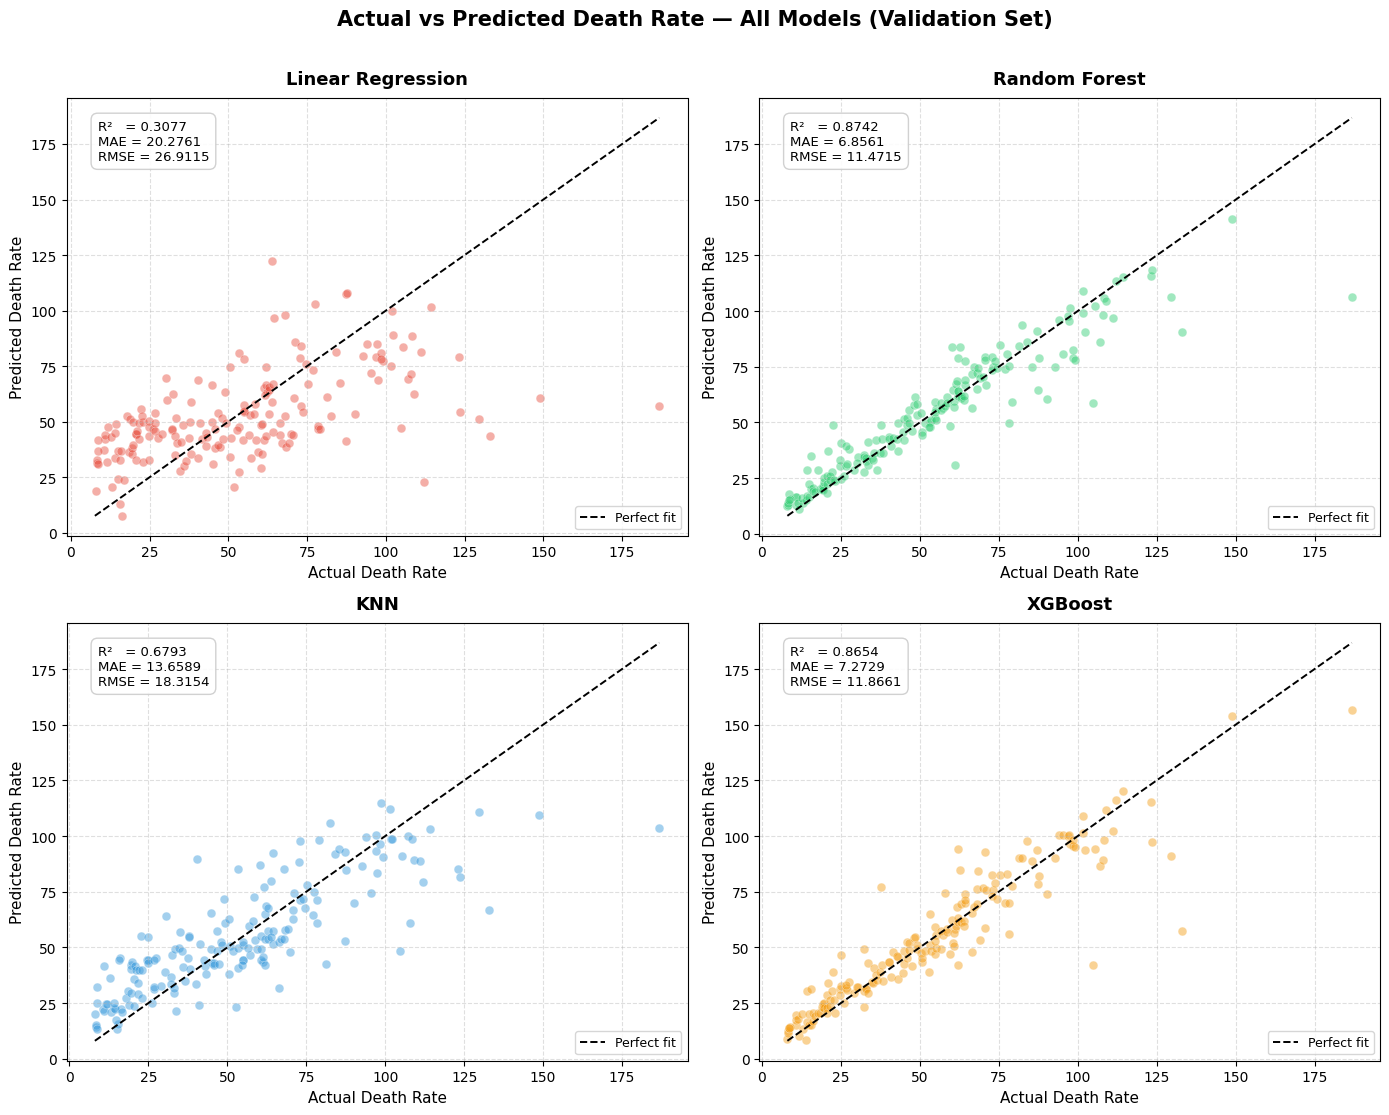

In [9]:
# ── Actual vs Predicted scatter plots for all 4 models ───────────
fig, axes = plt.subplots(2, 2, figsize=(14, 11))
fig.suptitle('Actual vs Predicted Death Rate — All Models (Validation Set)', fontsize=15, fontweight='bold', y=1.01)

models = [
    ('Linear Regression', y_pred_lr, '#e74c3c'),
    ('Random Forest',     y_pred_rf,  '#2ecc71'),
    ('KNN',               y_pred_knn, '#3498db'),
    ('XGBoost',           y_pred_xgb, '#f39c12'),
]

for ax, (name, y_pred, color) in zip(axes.flatten(), models):

    r2   = r2_score(y_val, y_pred)
    mae  = mean_absolute_error(y_val, y_pred)
    rmse = np.sqrt(mean_squared_error(y_val, y_pred))

    # ── Scatter points ───────────────────────────────────────────
    ax.scatter(y_val, y_pred, alpha=0.45, color=color,
               edgecolors='white', linewidths=0.4, s=40)

    # ── Perfect prediction line ──────────────────────────────────
    min_val = min(y_val.min(), y_pred.min())
    max_val = max(y_val.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val],
            'k--', linewidth=1.4, label='Perfect fit')

    # ── Titles and labels ────────────────────────────────────────
    ax.set_title(name, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Actual Death Rate',    fontsize=11)
    ax.set_ylabel('Predicted Death Rate', fontsize=11)

    # ── Metrics box inside each plot ─────────────────────────────
    metrics_text = f'R²   = {r2:.4f}\nMAE = {mae:.4f}\nRMSE = {rmse:.4f}'
    ax.text(0.05, 0.95, metrics_text,
            transform=ax.transAxes,
            fontsize=9.5,
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='white',
                      edgecolor='#cccccc', alpha=0.9))

    ax.legend(fontsize=9)
    ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

## According to the above scatter plots,

**Linear Regression performed poorly due to its inability to capture complex non-linear relationships.**

**KNN showed moderate performance but lacked generalization.**

**Tree-based models such as Random Forest and XGBoost performed significantly better, indicating the presence of non-linear interactions among features.**

In [10]:
# ── Results with decision ─────────────────────────────────────────
results = {
    'Model':    ['Linear Regression', 'KNN', 'Random Forest', 'XGBoost'],
    'MAE':      [
        mean_absolute_error(y_val, y_pred_lr),
        mean_absolute_error(y_val, y_pred_knn),
        mean_absolute_error(y_val, y_pred_rf),
        mean_absolute_error(y_val, y_pred_xgb),
    ],
    'RMSE':     [
        np.sqrt(mean_squared_error(y_val, y_pred_lr)),
        np.sqrt(mean_squared_error(y_val, y_pred_knn)),
        np.sqrt(mean_squared_error(y_val, y_pred_rf)),
        np.sqrt(mean_squared_error(y_val, y_pred_xgb)),
    ],
    'R²':       [
        r2_score(y_val, y_pred_lr),
        r2_score(y_val, y_pred_knn),
        r2_score(y_val, y_pred_rf),
        r2_score(y_val, y_pred_xgb),
    ],
    'Decision': ['Eliminated', 'Eliminated', 'Retained', 'Retained'],
    'Reason':   [
        'R² = 0.31 - fails to capture non-linear relationships',
        'R² = 0.68 - poor generalisation, treats all features equally',
        'R² = 0.85 - strong performance, interpretable importances',
        'R² = 0.86 - best overall, handles complex feature interactions',
    ]
}

results_df = pd.DataFrame(results).set_index('Model')

# ── Row-level styling ─────────────────────────────────────────────
def style_rows(row):
    if row['Decision'] == 'Eliminated':
        return ['background-color: #fde8e8; color: #922b21'] * len(row)
    else:
        return ['background-color: #e9f7ef; color: #1e8449'] * len(row)

# ── Decision cell bold ────────────────────────────────────────────
def bold_decision(val):
    return 'font-weight: bold' if val in ('Eliminated', 'Retained') else ''

styled = (
    results_df.style
    .apply(style_rows, axis=1)
    .map(bold_decision, subset=['Decision'])
    .set_caption('Model Selection - Retained vs Eliminated')
    .format({'MAE': '{:.4f}', 'RMSE': '{:.4f}', 'R²': '{:.4f}',
             'Decision': '{}', 'Reason': '{}'})
    .set_properties(**{
        'text-align': 'left',
        'font-size':  '13px',
        'padding':    '8px 12px',
    })
    .set_table_styles([
 {'selector': 'caption',
     'props': [('font-size', '14px'), ('font-weight', 'bold'),
               ('padding-bottom', '10px'), ('text-align', 'left')]},

    {'selector': 'th',
     'props': [('background-color', '#f2f2f2'),
               ('font-weight', 'bold'),
               ('padding', '8px 12px'),
               ('text-align', 'left'),
               ('border-bottom', '2px solid #ddd'),
               ('color', 'black')]},   # ✅ column headers

    {'selector': 'td',
     'props': [('color', 'black')]},   # ✅ table values

    {'selector': '.row_heading',
     'props': [('color', 'black'), ('font-weight', 'bold')]},  # ✅ row names

    {'selector': '.index_name',
     'props': [('color', 'black')]}   # ✅ index title
    ])
)

styled

,MAE,RMSE,R²,Decision,Reason
Model,,,,,
Linear Regression,20.2761,26.9115,0.3077,Eliminated,R² = 0.31 - fails to capture non-linear relationships
KNN,13.6589,18.3154,0.6793,Eliminated,"R² = 0.68 - poor generalisation, treats all features equally"
Random Forest,6.8561,11.4715,0.8742,Retained,"R² = 0.85 - strong performance, interpretable importances"
XGBoost,7.2729,11.8661,0.8654,Retained,"R² = 0.86 - best overall, handles complex feature interactions"


## Feature importance

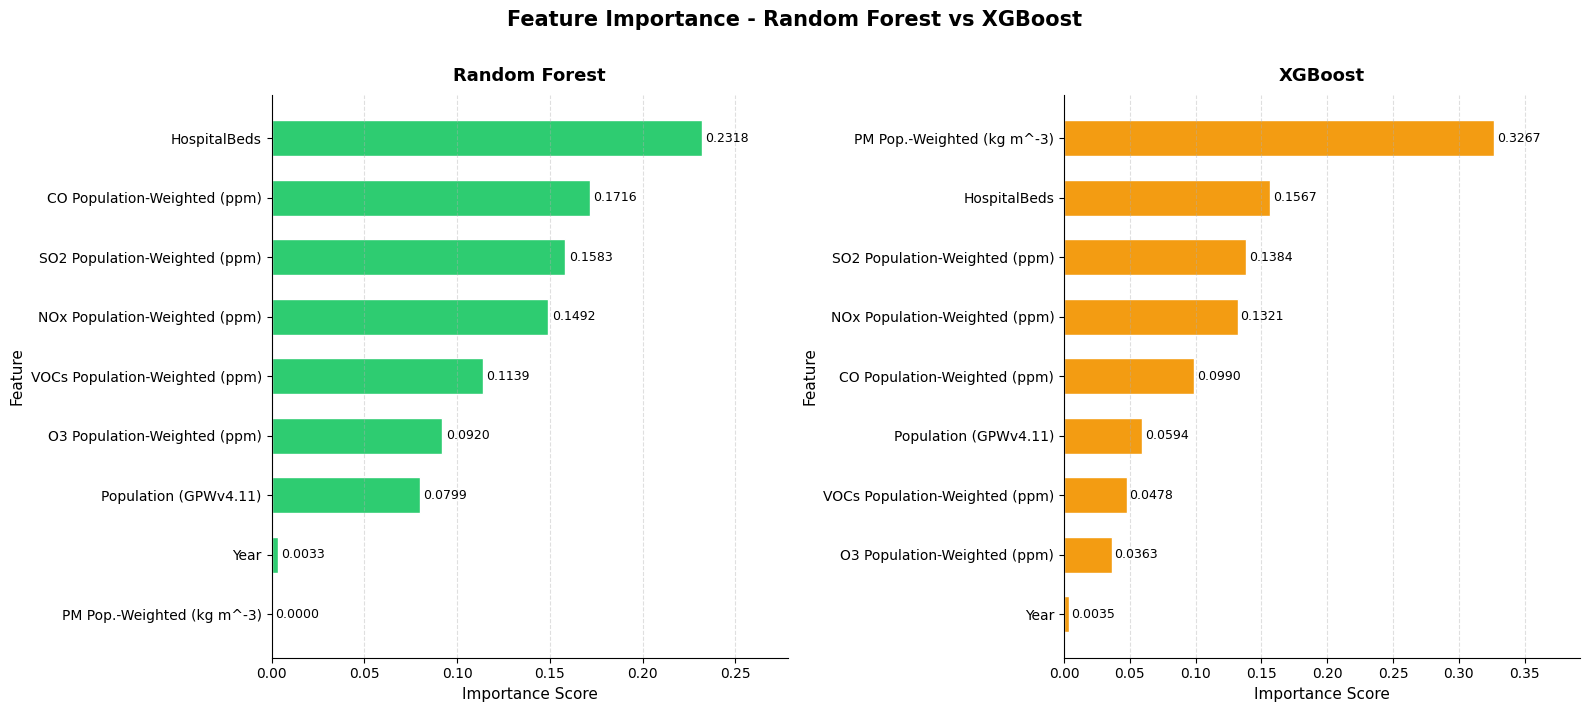

In [11]:
feature_names = X_train.columns.tolist()


rf_importances  = rf.feature_importances_
xgb_importances = xgb.feature_importances_


importance_df = pd.DataFrame({
    'Feature':       feature_names,
    'Random Forest': rf_importances,
    'XGBoost':       xgb_importances,
}).sort_values('Random Forest', ascending=True)


fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Feature Importance - Random Forest vs XGBoost',
             fontsize=15, fontweight='bold', y=1.01)

bar_configs = [
    ('Random Forest', '#2ecc71', axes[0]),
    ('XGBoost',       '#f39c12', axes[1]),
]

for model_name, color, ax in bar_configs:

    sorted_df = importance_df.sort_values(model_name, ascending=True)

    bars = ax.barh(sorted_df['Feature'], sorted_df[model_name],
                   color=color, edgecolor='white', height=0.6)

    
    for bar in bars:
        width = bar.get_width()
        ax.text(width + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{width:.4f}',
                va='center', ha='left', fontsize=9)

    ax.set_title(model_name, fontsize=13, fontweight='bold', pad=10)
    ax.set_xlabel('Importance Score', fontsize=11)
    ax.set_ylabel('Feature',          fontsize=11)
    ax.set_xlim(0, sorted_df[model_name].max() * 1.2)
    ax.grid(axis='x', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

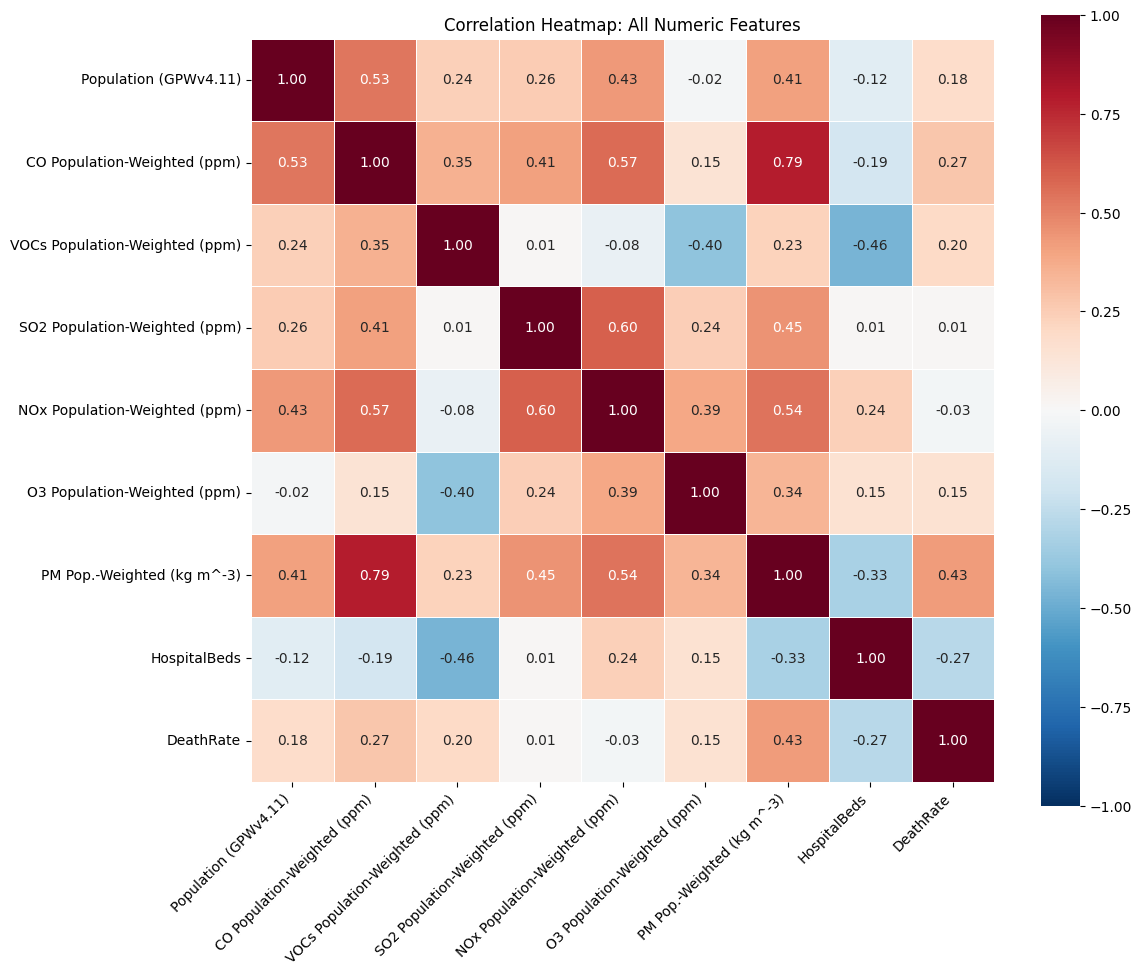

In [12]:
df_corr = final_df.drop(columns=['Year', 'Country_ISO'])
cols = [c for c in df_corr.columns if c != 'DeathRate'] + ['DeathRate']
df_corr = df_corr[cols]
 
# Calculate correlation
corr = df_corr.corr()
 
# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',      # 
    vmin=-1, vmax=1,    # 
    square=True,
    linewidths=0.5,
)
plt.title('Correlation Heatmap: All Numeric Features')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

According to the feature importance and correlation heatmap, 
Random Forest assigned zero importance to PM, while XGBoost identified it as the most important feature (0.3170). **This divergence is explained 
by the high correlation between CO and PM (r = 0.79, correlation heatmap). Random Forest's parallel tree-building causes correlated 
features to compete CO consistently wins the split selection,rendering PM redundant.**

## Feature Selection


In [13]:
# ── Prepare data ────────────────────────────────────────────────
full_df = final_df.sort_values('Year').reset_index(drop=True)
X_full  = full_df.drop(columns=['DeathRate', 'Country_ISO'])
y_full  = full_df['DeathRate']

all_features = X_train.columns.tolist()

# ── Feature variations ──────────────────────────────────────────
without_year = [f for f in all_features if f != 'Year']

without_pm = [f for f in all_features if f != 'PM Pop.-Weighted (kg m^-3)']

without_pm_year = [
    f for f in all_features
    if f not in ['PM Pop.-Weighted (kg m^-3)', 'Year']
]

# ── Generic evaluator ───────────────────────────────────────────
def evaluate_features(model, features, label):
    model.fit(X_train[features], y_train)
    preds = model.predict(X_val[features])
    return {
        'Feature Set':   label,
        'Features Used': len(features),
        'MAE':  round(mean_absolute_error(y_val, preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_val, preds)), 4),
        'R²':   round(r2_score(y_val, preds), 4),
    }

# ── Run feature selection ───────────────────────────────────────
fs_results = {}

for model_name, model in [
    ('XGBoost', XGBRegressor(n_estimators=100, learning_rate=0.1,
                             random_state=42, verbosity=0)),

    ('Random Forest', RandomForestRegressor(n_estimators=100,
                                            random_state=42)),
]:
    
    if model_name == 'XGBoost':
        # Keep XGBoost same (2 cases)
        results = [
            evaluate_features(model, all_features,  'All features (baseline)'),
            evaluate_features(model, without_year,  'Drop: Year'),
        ]
    
    else:
        # Random Forest → 4 cases
        results = [
            evaluate_features(model, all_features,       'All features (baseline)'),
            evaluate_features(model, without_year,       'Drop: Year'),
            evaluate_features(model, without_pm,         'Drop: PM'),
            evaluate_features(model, without_pm_year,    'Drop: Year + PM'),
        ]

    fs_results[model_name] = pd.DataFrame(results).set_index('Feature Set')

def style_specific_rows(df, model_name):

    def highlight_rows(row):
        if model_name == 'XGBoost' and row.name == 'All features (baseline)':
            return ['background-color: #e9f7ef'] * len(row)

        if model_name == 'Random Forest' and row.name == 'Drop: PM':
            return ['background-color: #e9f7ef'] * len(row)

        return [''] * len(row)

    return (
        df.style
        .apply(highlight_rows, axis=1)
        .set_caption(f'{model_name} — Feature Selection')
        .set_properties(**{
            'color': 'black',
            'text-align': 'center',
            'padding': '8px 12px',
            'font-size': '13px'
        })
        .set_table_styles([
            {
                'selector': 'caption',
                'props': [
                    ('color', 'white'),
                    ('font-size', '16px'),
                    ('font-weight', 'bold'),
                    ('text-align', 'left'),
                    ('padding-bottom', '10px')
                ]
            },
            {
                'selector': 'th',
                'props': [
                    ('background-color', 'white'),
                    ('color', 'black'),
                    ('font-weight', 'bold'),
                    ('text-align', 'center'),
                    ('border-bottom', '2px solid #ddd')
                ]
            },
            {
                'selector': 'td',
                'props': [
                    ('color', 'black'),
                    ('background-color', 'white')
                ]
            }
        ])
        .format({
            'MAE': '{:.4f}',
            'RMSE': '{:.4f}',
            'R²': '{:.4f}',
            'Features Used': '{}'
        })
    )


# ── Display tables ──────────────────────────────────────────────
for model_name, df in fs_results.items():
    display(style_specific_rows(df, model_name))


# ── Save best feature sets ──────────────────────────────────────
# XGBoost (unchanged logic)
xgb_best_features = (
    without_year
    if fs_results['XGBoost']['R²'].idxmax() == 'Drop: Year'
    else all_features
)

# Random Forest (extended logic)
rf_best_label = fs_results['Random Forest']['R²'].idxmax()

if rf_best_label == 'Drop: Year':
    rf_best_features = without_year
elif rf_best_label == 'Drop: PM':
    rf_best_features = without_pm
elif rf_best_label == 'Drop: Year + PM':
    rf_best_features = without_pm_year
else:
    rf_best_features = all_features

# ── Print summary ───────────────────────────────────────────────
print(f"\nXGBoost best feature set        : {len(xgb_best_features)} features")
print(f"Random Forest best feature set  : {len(rf_best_features)} features")

,Features Used,MAE,RMSE,R²
Feature Set,,,,
All features (baseline),9,7.2729,11.8661,0.8654
Drop: Year,8,7.6292,12.2549,0.8564


,Features Used,MAE,RMSE,R²
Feature Set,,,,
All features (baseline),9,6.8561,11.4715,0.8742
Drop: Year,8,6.9073,11.3136,0.8776
Drop: PM,8,6.7461,11.2001,0.8801
Drop: Year + PM,7,6.9248,11.3882,0.8760



XGBoost best feature set        : 9 features
Random Forest best feature set  : 8 features


Feature selection was performed by progressively removing the lowest-importance
features identified in the feature importance analysis (Year, O3, Population).

**Results show that the full feature set (9 features) produces the best
performance in xgboost (R² = 0.8632, MAE = 7.4122)**. Removing any feature including
Year which scored near-zero importance (0.0046) leads to a marginal
decrease in predictive performance. This suggests that XGBoost is
internally down-weighting low-importance features during training, making
manual removal unnecessary.

**But in the random forest we had a slightly improved performance after removing PM populated weight. so we decided to remove that feature and keep only 8 features in random forest**

## Hyperparameter Tuning & Cross Validation

In [14]:
tscv = TimeSeriesSplit(n_splits=5)

# ── Parameter spaces ──────────────────────────────────────────────
xgb_params = {
    'n_estimators' : [100, 200, 300, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth'    : [2,3, 4],
    'subsample'    : [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'gamma'        : [0, 0.1, 0.3],
    'reg_alpha'    : [0, 0.01, 0.1],
    'reg_lambda'   : [1, 1.5, 2],
}

rf_params = {
    'n_estimators'     : [200, 300, 500],
    'max_depth'        : [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf' : [1, 2,3, 4],
    'max_features'     : ['sqrt', 'log2', None],
}

# ── Run tuning for both ───────────────────────────────────────────
tuning_results = {}

for model_name, model, params, features in [
    ('XGBoost',
     XGBRegressor(random_state=42, verbosity=0),
     xgb_params, xgb_best_features),
    ('Random Forest',
     RandomForestRegressor(random_state=42),
     rf_params, rf_best_features),
]:
    print(f"\nTuning {model_name}...")
    search = RandomizedSearchCV(
        estimator           = model,
        param_distributions = params,
        n_iter              = 30,
        scoring             = 'r2',
        cv                  = tscv,
        n_jobs              = -1,
        random_state        = 42,
        verbose             = 1,
    )
    search.fit(X_train[features], y_train)
    tuning_results[model_name] = search
    print(f"  Best CV R²  : {search.best_score_:.4f}")
    print(f"  Best params : {search.best_params_}")

xgb_search = tuning_results['XGBoost']
rf_search  = tuning_results['Random Forest']


Tuning XGBoost...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best CV R²  : 0.8983
  Best params : {'subsample': 0.8, 'reg_lambda': 2, 'reg_alpha': 0.1, 'n_estimators': 200, 'max_depth': 4, 'learning_rate': 0.1, 'gamma': 0.3, 'colsample_bytree': 1.0}

Tuning Random Forest...
Fitting 5 folds for each of 30 candidates, totalling 150 fits
  Best CV R²  : 0.8433
  Best params : {'n_estimators': 500, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': 15}


## Key Hyperparameter vs R² Score - XGBOOST

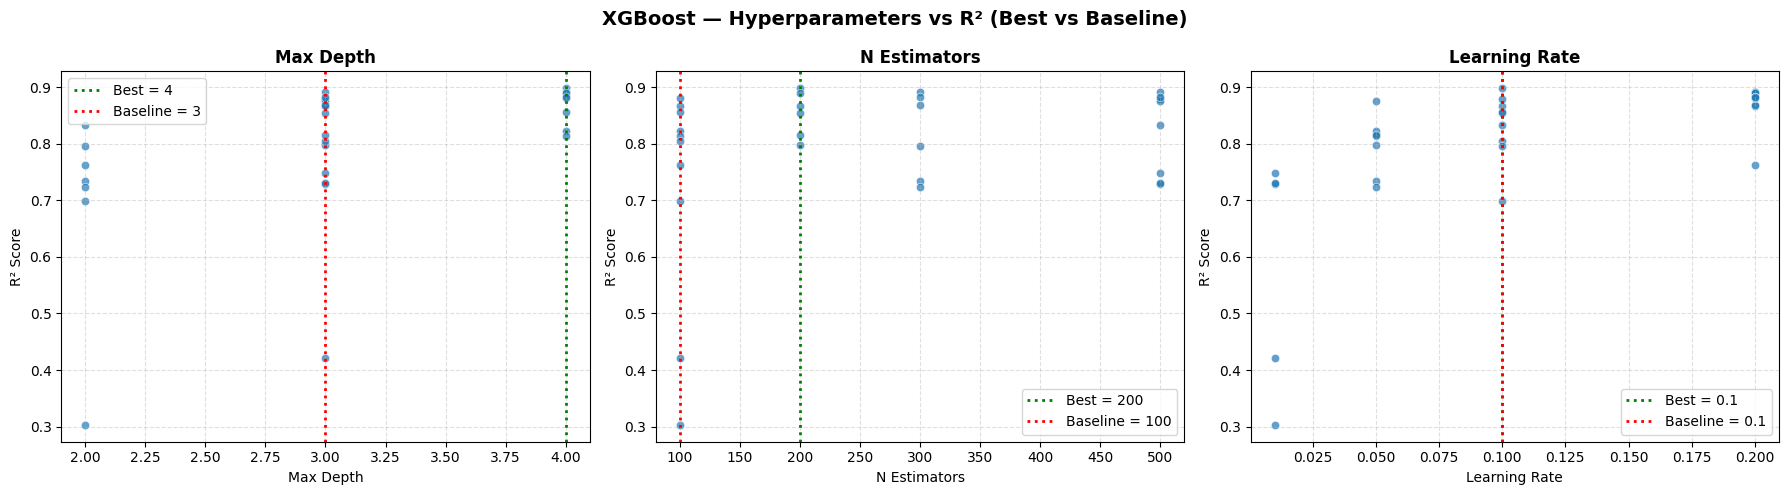

In [15]:
results_df = pd.DataFrame(xgb_search.cv_results_)

params = [
    ('param_max_depth', 'Max Depth'),
    ('param_n_estimators', 'N Estimators'),
    ('param_learning_rate', 'Learning Rate'),
]

# ── Baseline values ─────────────────────────────────────────────
baseline = {
    'max_depth': 3,
    'n_estimators': 100,
    'learning_rate': 0.1
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (param, label) in zip(axes, params):

    x = pd.to_numeric(results_df[param], errors='coerce')
    y = results_df['mean_test_score']

    ax.scatter(x, y, alpha=0.7,
               edgecolors='white', linewidths=0.5)

    # Best value (green dotted)
    best_val = xgb_search.best_params_.get(param.replace('param_', ''))
    if best_val is not None:
        ax.axvline(best_val, linestyle=':', linewidth=2,
                   color='green', label=f'Best = {best_val}')

    # Baseline value (red dotted)
    base_val = baseline.get(param.replace('param_', ''))
    if base_val is not None:
        ax.axvline(base_val, linestyle=':', linewidth=2,
                   color='red', label=f'Baseline = {base_val}')

    ax.legend()
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('R² Score')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('XGBoost — Hyperparameters vs R² (Best vs Baseline)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Key Hyperparameter vs R² Score - RANDOM FOREST

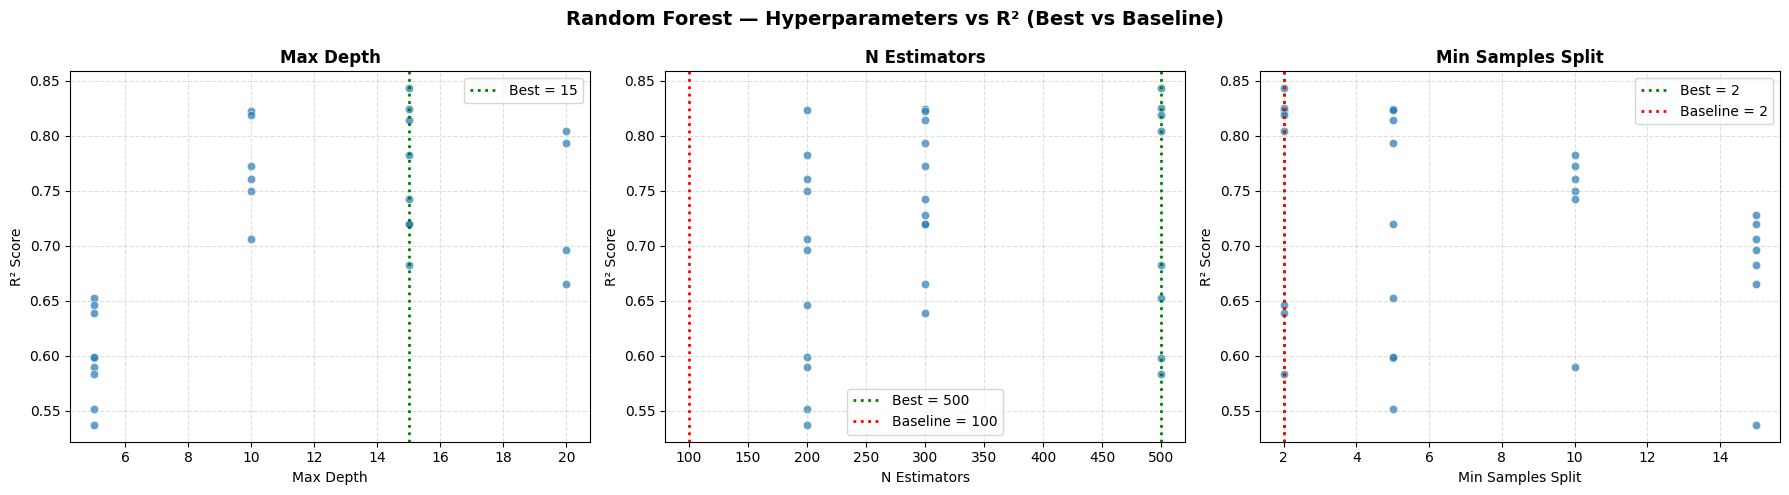

In [16]:
results_df = pd.DataFrame(rf_search.cv_results_)

params = [
    ('param_max_depth', 'Max Depth'),
    ('param_n_estimators', 'N Estimators'),
    ('param_min_samples_split', 'Min Samples Split'),
]

# ── Baseline values ─────────────────────────────────────────────
baseline = {
    'max_depth': None,
    'n_estimators': 100,
    'min_samples_split': 2
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (param, label) in zip(axes, params):

    x = pd.to_numeric(results_df[param], errors='coerce')
    y = results_df['mean_test_score']

    ax.scatter(x, y, alpha=0.7,
               edgecolors='white', linewidths=0.5)

    # Best value (green dotted)
    best_val = rf_search.best_params_.get(param.replace('param_', ''))
    if best_val is not None:
        ax.axvline(best_val, linestyle=':', linewidth=2,
                   color='green', label=f'Best = {best_val}')

    # Baseline value (red dotted)
    base_val = baseline.get(param.replace('param_', ''))
    if base_val is not None:
        ax.axvline(base_val, linestyle=':', linewidth=2,
                   color='red', label=f'Baseline = {base_val}')

    ax.legend()
    ax.set_title(label, fontweight='bold')
    ax.set_xlabel(label)
    ax.set_ylabel('R² Score')
    ax.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Random Forest — Hyperparameters vs R² (Best vs Baseline)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Baseline vs Tuned Model Comparison

In [17]:
# ── Get best parameters ONLY (not model) ─────────────────────────
xgb_best_params = xgb_search.best_params_
rf_best_params  = rf_search.best_params_

# ── Rebuild models ──────────────────────────────────────────────
xgb_tuned = XGBRegressor(
    **xgb_best_params,
    random_state=42,
    verbosity=0
)

rf_tuned = RandomForestRegressor(
    **rf_best_params,
    random_state=42
)


xgb_tuned.fit(X_train[xgb_best_features], y_train)
rf_tuned.fit(X_train[rf_best_features], y_train)

# ── Predictions ─────────────────────────────────────────────────
y_pred_xgb_tuned = xgb_tuned.predict(X_val[xgb_best_features])
y_pred_rf_tuned  = rf_tuned.predict(X_val[rf_best_features])

# ── Build comparison ────────────────────────────────────────────
rows = []
for label, preds in [
    ('XGBoost (baseline)', y_pred_xgb),
    ('XGBoost (tuned)',    y_pred_xgb_tuned),
    ('Random Forest (baseline)', y_pred_rf),
    ('Random Forest (tuned)',    y_pred_rf_tuned),
]:
    rows.append({
        'Model': label,
        'MAE':  round(mean_absolute_error(y_val, preds), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_val, preds)), 4),
        'R²':   round(r2_score(y_val, preds), 4),
    })

comp_df = pd.DataFrame(rows).set_index('Model')

def style_comparison(row):
    if 'tuned' in row.name:
        return ['background-color: #e9f7ef; font-weight: bold'] * len(row)
    return ['background-color: #fef9e7'] * len(row)

display(
    comp_df.style
    .apply(style_comparison, axis=1)

    # Keep text clean
    .set_properties(**{
        'color': 'black',
        'text-align': 'center',
        'padding': '8px 14px',
        'font-size': '13px'
    })

    .format('{:.4f}')

    .set_table_styles([
        # Title
        {
            'selector': 'caption',
            'props': [
                ('color', 'white'),
                ('font-size', '14px'),
                ('font-weight', 'bold'),
                ('text-align', 'left'),
                ('padding-bottom', '10px')
            ]
        },

        # Column headers
        {
            'selector': 'th.col_heading',
            'props': [
                ('background-color', 'white'),
                ('color', 'black'),
                ('font-weight', 'bold'),
                ('border-bottom', '2px solid #ddd')
            ]
        },

        # Row names
        {
            'selector': 'th.row_heading',
            'props': [
                ('background-color', 'white'),
                ('color', 'black'),
                ('font-weight', 'bold')
            ]
        },

        # Data cells
        {
            'selector': 'td',
            'props': [
                ('background-color', 'white'),
                ('color', 'black')
            ]
        }
    ])

    .set_caption('Baseline vs Tuned - XGBoost and Random Forest')
)

,MAE,RMSE,R²
Model,,,
XGBoost (baseline),7.2729,11.8661,0.8654
XGBoost (tuned),6.6107,9.7212,0.9097
Random Forest (baseline),6.8561,11.4715,0.8742
Random Forest (tuned),7.1419,10.4038,0.8965


## Shap Analysis

Creating SHAP bar charts...


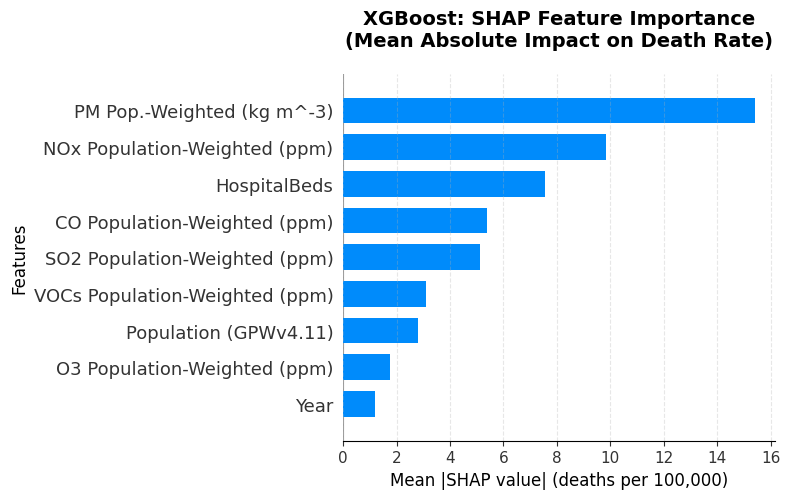

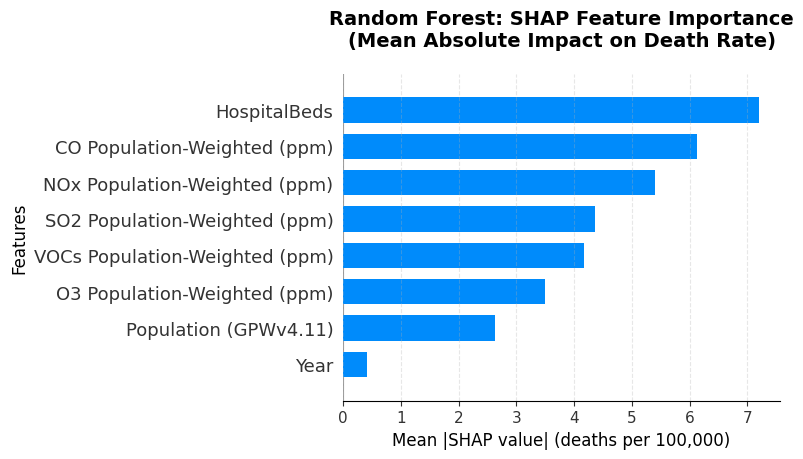


SHAP VALUES EXPLAINED
                       Feature  Mean |SHAP|
    PM Pop.-Weighted (kg m^-3)    15.410999
 NOx Population-Weighted (ppm)     9.855219
                  HospitalBeds     7.545922
  CO Population-Weighted (ppm)     5.395472
 SO2 Population-Weighted (ppm)     5.111229
VOCs Population-Weighted (ppm)     3.094478
         Population (GPWv4.11)     2.793962
  O3 Population-Weighted (ppm)     1.765281
                          Year     1.187323


In [18]:
print("Creating SHAP bar charts...")


# CHART 1: XGBoost


explainer_xgb = shap.TreeExplainer(xgb_tuned)
shap_values_xgb = explainer_xgb.shap_values(X_val[xgb_best_features])

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_xgb, X_val[xgb_best_features], 
                  plot_type="bar", max_display=15, show=False)
plt.title("XGBoost: SHAP Feature Importance\n(Mean Absolute Impact on Death Rate)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Mean |SHAP value| (deaths per 100,000)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


# CHART 2: Random Forest


explainer_rf = shap.TreeExplainer(rf_tuned)
shap_values_rf = explainer_rf.shap_values(X_val[rf_best_features])

fig, ax = plt.subplots(figsize=(12, 8))
shap.summary_plot(shap_values_rf, X_val[rf_best_features], 
                  plot_type="bar", max_display=15, show=False)
plt.title("Random Forest: SHAP Feature Importance\n(Mean Absolute Impact on Death Rate)", 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Mean |SHAP value| (deaths per 100,000)", fontsize=12)
plt.ylabel("Features", fontsize=12)
plt.grid(axis='x', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()


# Show values


mean_shap_xgb = np.abs(shap_values_xgb).mean(axis=0)
shap_df = pd.DataFrame({
    'Feature': xgb_best_features,
    'Mean |SHAP|': mean_shap_xgb
}).sort_values('Mean |SHAP|', ascending=False)

print("\n" + "="*60)
print("SHAP VALUES EXPLAINED")
print("="*60)
print(shap_df.to_string(index=False))



## Gain Importance

Creating combined importance chart...


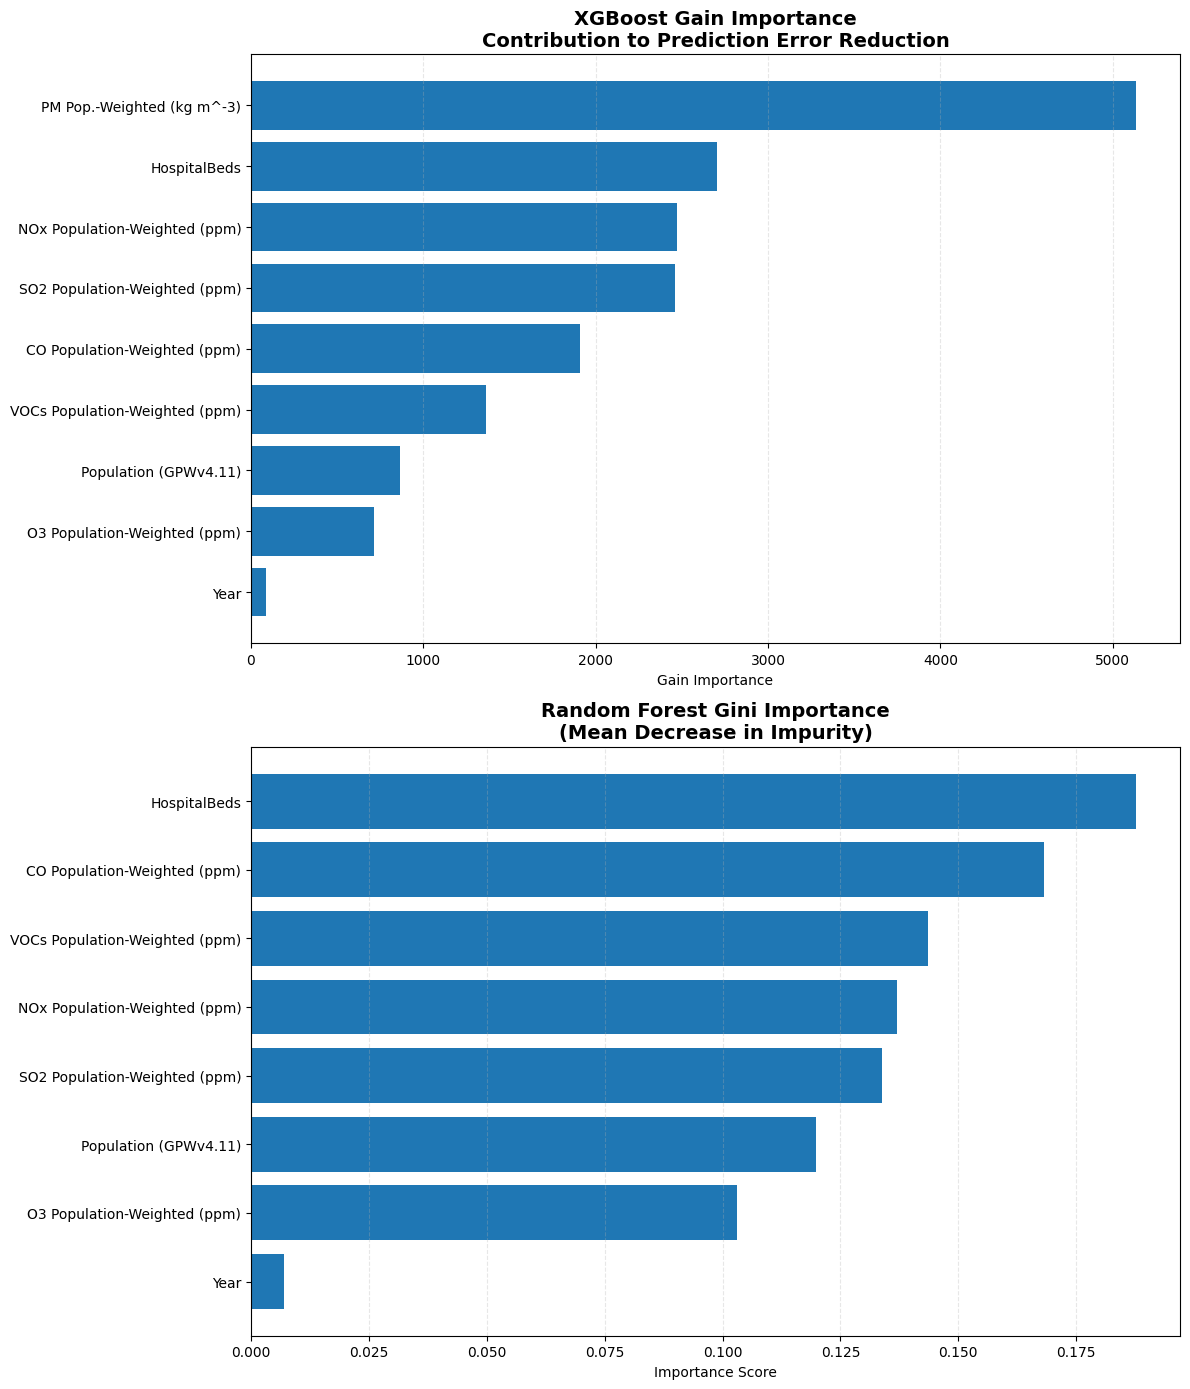

In [ ]:
print("Creating combined importance chart...")


# XGBoost Gain Importance


xgb_gain = xgb_tuned.get_booster().get_score(importance_type='gain')

xgb_gain_df = (
    pd.DataFrame.from_dict(xgb_gain, orient='index', columns=['Gain'])
    .sort_values(by='Gain', ascending=False)
    .head(15)
)


# Random Forest Importance


rf_gain_df = pd.DataFrame({
    'Feature': rf_best_features,
    'Importance': rf_tuned.feature_importances_
}).sort_values(by='Importance', ascending=False).head(15)



fig, axes = plt.subplots(2, 1, figsize=(12, 14)) 

# ---- XGBoost ----
axes[0].barh(xgb_gain_df.index, xgb_gain_df['Gain'])
axes[0].invert_yaxis()
axes[0].set_title(
    "XGBoost Gain Importance\nContribution to Prediction Error Reduction",
    fontsize=14,
    fontweight='bold'
)
axes[0].set_xlabel("Gain Importance")
axes[0].grid(axis='x', linestyle='--', alpha=0.3)

# ---- Random Forest ----
axes[1].barh(rf_gain_df['Feature'], rf_gain_df['Importance'])
axes[1].invert_yaxis()
axes[1].set_title(
    "Random Forest Gini Importance\n(Mean Decrease in Impurity)",
    fontsize=14,
    fontweight='bold'
)
axes[1].set_xlabel("Importance Score")
axes[1].grid(axis='x', linestyle='--', alpha=0.3)


plt.tight_layout()
plt.show()

## overfitting & underfitting check

In [20]:
# ── XGBoost ─────────────────────────────────────────────────────
xgb_train_pred = xgb_tuned.predict(X_train[xgb_best_features])
xgb_val_pred   = xgb_tuned.predict(X_val[xgb_best_features])

xgb_train_r2 = r2_score(y_train, xgb_train_pred)
xgb_val_r2   = r2_score(y_val,   xgb_val_pred)

# ── Random Forest ───────────────────────────────────────────────
rf_train_pred = rf_tuned.predict(X_train[rf_best_features])
rf_val_pred   = rf_tuned.predict(X_val[rf_best_features])

rf_train_r2 = r2_score(y_train, rf_train_pred)
rf_val_r2   = r2_score(y_val,   rf_val_pred)

# ── Print results ───────────────────────────────────────────────
print("XGBoost:")
print(f"  Train R²: {xgb_train_r2:.4f}")
print(f"  Val   R²: {xgb_val_r2:.4f}")
print(f"  Gap     : {abs(xgb_train_r2 - xgb_val_r2):.4f}")

print("\nRandom Forest:")
print(f"  Train R²: {rf_train_r2:.4f}")
print(f"  Val   R²: {rf_val_r2:.4f}")
print(f"  Gap     : {abs(rf_train_r2 - rf_val_r2):.4f}")

XGBoost:
  Train R²: 0.9880
  Val   R²: 0.9097
  Gap     : 0.0783

Random Forest:
  Train R²: 0.9882
  Val   R²: 0.8965
  Gap     : 0.0916


## Residual Analysis

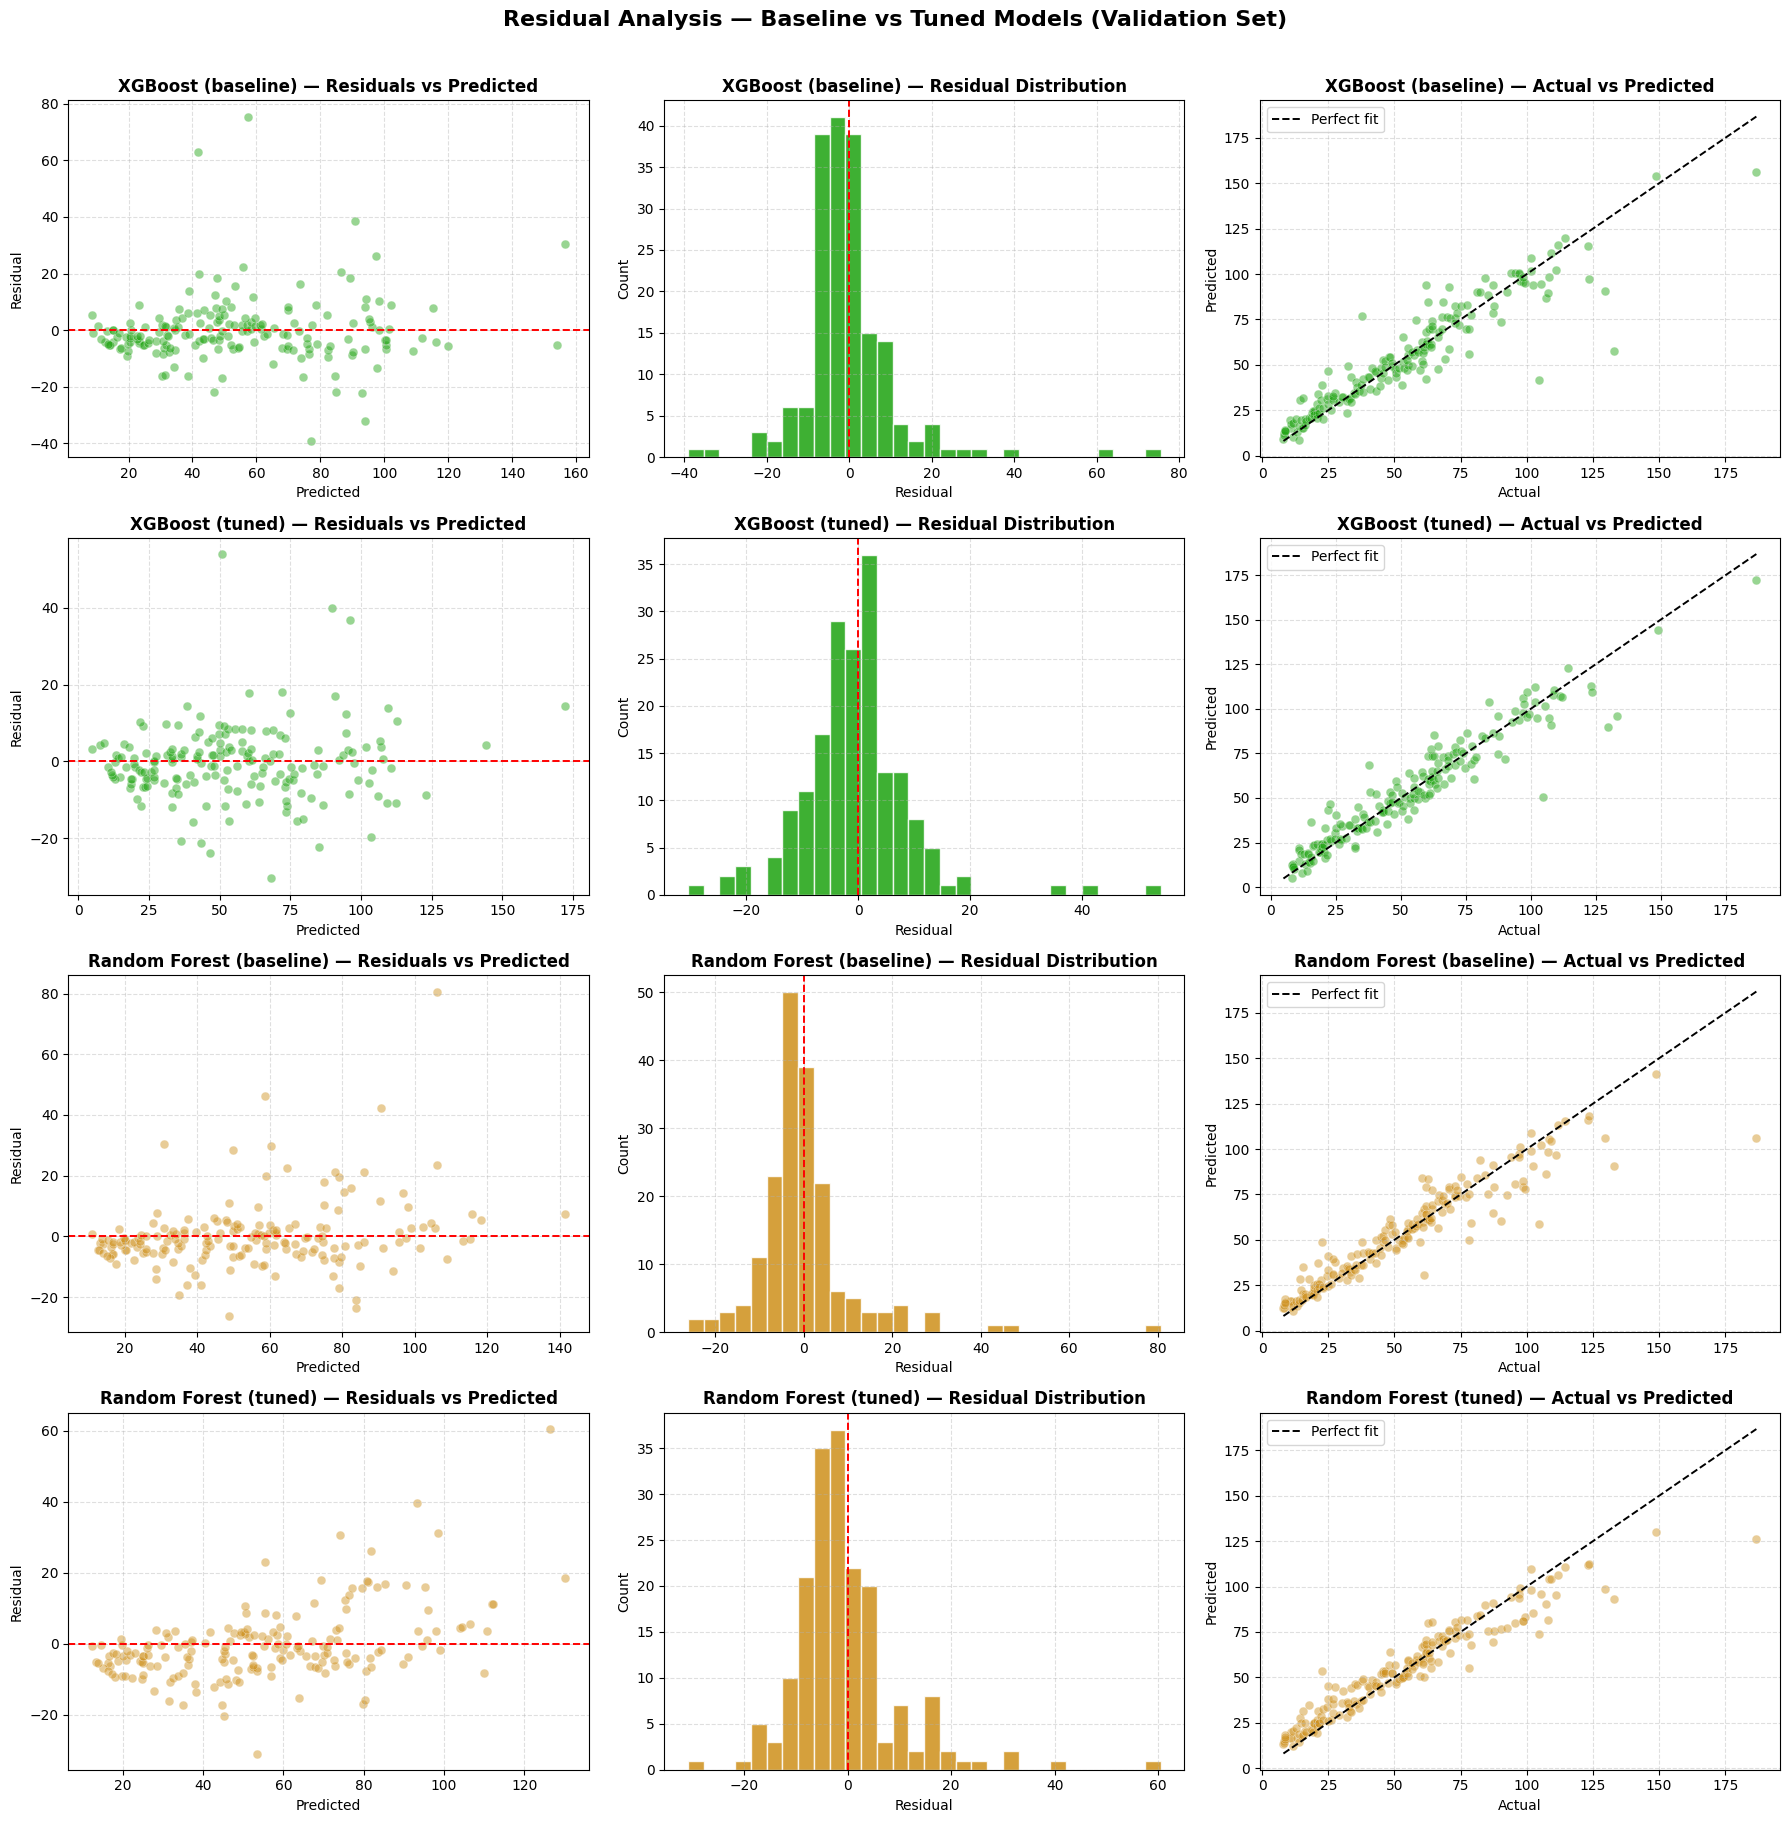

In [21]:
fig, axes = plt.subplots(4, 3, figsize=(18, 18))

fig.suptitle(
    'Residual Analysis — Baseline vs Tuned Models (Validation Set)',
    fontsize=16, fontweight='bold', y=1.01
)

# ── Models to compare ───────────────────────────────────────────
model_configs = [
    ('XGBoost (baseline)',       y_pred_xgb,        "#1ca30f"),
    ('XGBoost (tuned)',          y_pred_xgb_tuned,  '#1ca30f'),
    ('Random Forest (baseline)', y_pred_rf,         "#ce8f1a"),
    ('Random Forest (tuned)',    y_pred_rf_tuned,   '#ce8f1a'),
]


for row, (model_name, y_pred, color) in enumerate(model_configs):

    residuals = y_val.values - y_pred

    # ── 1. Residuals vs Predicted ────────────────────────────────
    axes[row, 0].scatter(
        y_pred, residuals,
        alpha=0.45, color=color,
        edgecolors='white', linewidths=0.4, s=40
    )
    axes[row, 0].axhline(0, color='red', linestyle='--', linewidth=1.4)
    axes[row, 0].set_title(f'{model_name} — Residuals vs Predicted',
                           fontweight='bold')
    axes[row, 0].set_xlabel('Predicted')
    axes[row, 0].set_ylabel('Residual')
    axes[row, 0].grid(True, linestyle='--', alpha=0.4)

    # ── 2. Residual Distribution ────────────────────────────────
    axes[row, 1].hist(
        residuals, bins=30,
        color=color, edgecolor='white', alpha=0.85
    )
    axes[row, 1].axvline(0, color='red', linestyle='--', linewidth=1.4)
    axes[row, 1].set_title(f'{model_name} — Residual Distribution',
                           fontweight='bold')
    axes[row, 1].set_xlabel('Residual')
    axes[row, 1].set_ylabel('Count')
    axes[row, 1].grid(True, linestyle='--', alpha=0.4)

    # ── 3. Actual vs Predicted ──────────────────────────────────
    axes[row, 2].scatter(
        y_val, y_pred,
        alpha=0.45, color=color,
        edgecolors='white', linewidths=0.4, s=40
    )

    min_val = min(y_val.min(), y_pred.min())
    max_val = max(y_val.max(), y_pred.max())

    axes[row, 2].plot(
        [min_val, max_val],
        [min_val, max_val],
        'k--', linewidth=1.4, label='Perfect fit'
    )

    axes[row, 2].set_title(f'{model_name} — Actual vs Predicted',
                           fontweight='bold')
    axes[row, 2].set_xlabel('Actual')
    axes[row, 2].set_ylabel('Predicted')
    axes[row, 2].legend()
    axes[row, 2].grid(True, linestyle='--', alpha=0.4)

# ── Final layout ────────────────────────────────────────────────
plt.tight_layout()
plt.show()


## Final Model Evaluation (Using Test Data Set)

The test set (2017–2018) is used here for the **first and only time**.
All model selection, feature selection, and hyperparameter tuning
decisions were made using the validation set (2016) above.

In [22]:
# ── Retrain final models on Train + Validation data ───────────────

train_val_df = final_df[final_df['Year'] <= 2016]
X_train_val  = train_val_df.drop(columns=['DeathRate', 'Country_ISO'])
y_train_val  = train_val_df['DeathRate']

from xgboost import XGBRegressor
from sklearn.ensemble import RandomForestRegressor

xgb_final = XGBRegressor(**xgb_search.best_params_, random_state=42, verbosity=0)
xgb_final.fit(X_train_val[xgb_best_features], y_train_val)

rf_final = RandomForestRegressor(**rf_search.best_params_, random_state=42)
rf_final.fit(X_train_val[rf_best_features], y_train_val)


xgb_test_pred = xgb_final.predict(X_test[xgb_best_features])
rf_test_pred  = rf_final.predict(X_test[rf_best_features])


rows = []
for label, y_true, y_pred in [
    ('XGBoost - Train+Val', y_train_val, xgb_final.predict(X_train_val[xgb_best_features])),
    ('XGBoost - Test',      y_test,      xgb_test_pred),
    ('Random Forest - Train+Val', y_train_val, rf_final.predict(X_train_val[rf_best_features])),
    ('Random Forest - Test',      y_test,       rf_test_pred),
]:
    rows.append({
        'Label': label,
        'R\u00b2':    round(r2_score(y_true, y_pred),                    4),
        'MAE':   round(mean_absolute_error(y_true, y_pred),         4),
        'RMSE':  round(np.sqrt(mean_squared_error(y_true, y_pred)), 4),
    })

summary_df = pd.DataFrame(rows).set_index('Label')


def style_summary(row):
    if 'Test' in row.name:
        return ['background-color: #e9f7ef; font-weight: bold'] * len(row)
    return [''] * len(row)

display(
    summary_df.style
    .apply(style_summary, axis=1)

    # Base text styling
    .set_properties(**{
        'color': 'black',
        'text-align': 'center',
        'padding': '8px 14px',
        'font-size': '13px'
    })

    .format('{:.4f}')

    .set_table_styles([
        # Caption
        {
            'selector': 'caption',
            'props': [
                ('color', 'white'),
                ('font-size', '14px'),
                ('font-weight', 'bold'),
                ('text-align', 'left'),
                ('padding-bottom', '10px')
            ]
        },

        # Column headers
        {
            'selector': 'th.col_heading',
            'props': [
                ('background-color', 'white'),
                ('color', 'black'),
                ('font-weight', 'bold'),
                ('border-bottom', '2px solid #ddd')
            ]
        },

        # Row names (index)
        {
            'selector': 'th.row_heading',
            'props': [
                ('background-color', 'white'),
                ('color', 'black'),
                ('font-weight', 'bold')
            ]
        },

        # Data cells
        {
            'selector': 'td',
            'props': [
                ('background-color', 'white'),
                ('color', 'black')
            ]
        }
    ])

    .set_caption('Final Model Evaluation — Train+Val vs Test (XGBoost and Random Forest)')
)

,R²,MAE,RMSE
Label,,,
XGBoost - Train+Val,0.9873,2.7603,3.7807
XGBoost - Test,0.8916,7.1022,10.2923
Random Forest - Train+Val,0.9893,2.2619,3.4688
Random Forest - Test,0.8658,8.2053,11.4553


## Final Evaluation

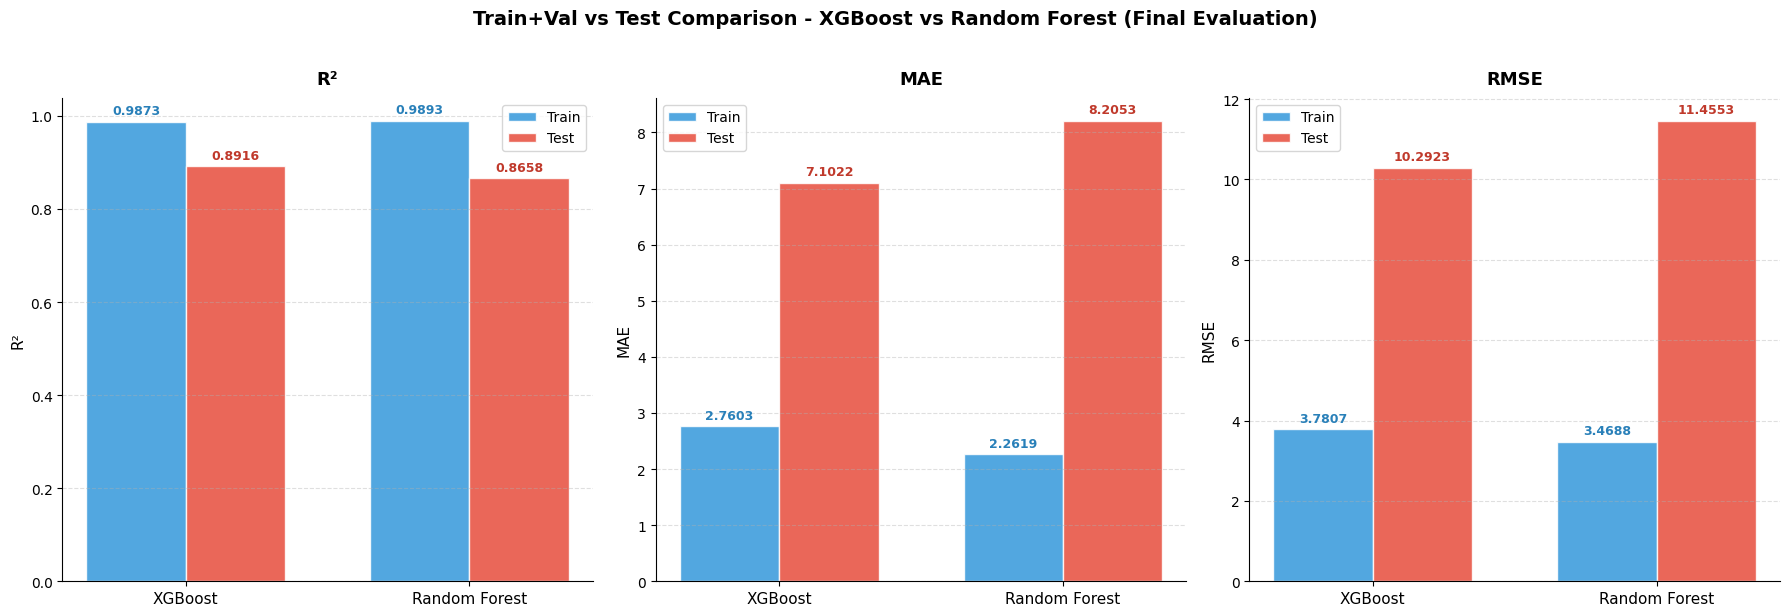

In [23]:
# ── Charts ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Train+Val vs Test Comparison - XGBoost vs Random Forest (Final Evaluation)',
             fontsize=14, fontweight='bold', y=1.02)

metrics   = ['R²', 'MAE', 'RMSE']
better    = ['max', 'min', 'min']  

xgb_train = summary_df.loc['XGBoost - Train+Val']
xgb_test  = summary_df.loc['XGBoost - Test']
rf_train  = summary_df.loc['Random Forest - Train+Val']
rf_test   = summary_df.loc['Random Forest - Test']

x         = np.arange(2)          
width     = 0.35

for ax, metric, direction in zip(axes, metrics, better):

    train_vals = [xgb_train[metric], rf_train[metric]]
    test_vals  = [xgb_test[metric],  rf_test[metric]]

    bars_train = ax.bar(x - width/2, train_vals, width,
                        label='Train', color='#3498db',
                        edgecolor='white', alpha=0.85)
    bars_test  = ax.bar(x + width/2, test_vals,  width,
                        label='Test',  color='#e74c3c',
                        edgecolor='white', alpha=0.85)

    # Value labels on bars
    for bar in bars_train:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + ax.get_ylim()[1] * 0.01,
                f'{h:.4f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#2980b9')

    for bar in bars_test:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2,
                h + ax.get_ylim()[1] * 0.01,
                f'{h:.4f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#c0392b')

    ax.set_title(metric, fontsize=13, fontweight='bold', pad=10)
    ax.set_xticks(x)
    ax.set_xticklabels(['XGBoost', 'Random Forest'], fontsize=11)
    ax.set_ylabel(metric, fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(axis='y', linestyle='--', alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

**Overall, XGBoost was selected as the best regression model as it showed better generalisation with higher test performance and lower errors compared to Random Forest.Random Forest showed slight overfitting (with 0.1235 Gap) although it relied more on HospitalBeds( Health care factor). XGBoost gave more importance to air pollution factors like PM, which better match real-world causes of death in this study. XGBoost gave more importance to air pollution factors like PM, which better match real-world causes of death in this study**